# 3D Brain Tumor Segmentation from MRI scans
**Author:** Vasilis Kourentzis | **Domain:** Neuroradiology / Oncology

### Executive Summary
This project demonstrates an end-to-end deep learning pipeline for the automated, multi-class segmentation of brain tumors from 3D MRI scans. Designed with clinical utility in mind, the model processes T1-weighted contrast-enhanced (T1ce) imaging to isolate active tumor regions, providing a foundation for automated volumetric analysis and surgical planning.

### Methodology & Tech Stack
* **Dataset:** Medical Segmentation Decathlon (MSD) Brain Tumor Dataset (NIfTI format).
* **Data Pipeline:** Engineered using **MONAI** for robust 3D spatial transformations, deterministic intensity normalization, and optimized tensor conversion.
* **Modeling & Evaluation:** Utilized **PyTorch** for model inference, mapping multi-dimensional predictions against ground-truth clinical annotations across Axial, Coronal, and Sagittal planes.
* **Clinical Relevance:** Mimics the requirements of Software as a Medical Device (SaMD) by automating repetitive low-level radiological tasks, ultimately streamlining the diagnostic workflow.

In [ ]:
# Visualizing patient 0 from our data
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from monai.apps import DecathlonDataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityd,
)

# 1. Setup GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Engine Active: {torch.cuda.get_device_name(0)}")

# 2. Define Transforms
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    ScaleIntensityd(keys=["image"]),
])

# 3. Download Data
# This will download ~1.5GB. It might take 2-5 minutes.
print("Downloading MSD Brain Tumor Dataset...")
root_dir = "./data"
train_ds = DecathlonDataset(
    root_dir=root_dir, 
    task="Task01_BrainTumour", 
    section="training", 
    transform=train_transforms, 
    download=True,
    cache_rate=0.0 
)
print(f"Dataset Ready. Total Patients: {len(train_ds)}")

# 4. Visualize Patient 0
data = train_ds[0]
image = data["image"]
label = data["label"]

# Visualization Function
def show_mri_channels(img, lbl, slice_idx=70):
    plt.figure(figsize=(12, 4))
    titles = ["FLAIR (Edema)", "T1 (Structure)", "T1ce (Active Tumor)", "T2", "Truth Mask"]
    
    for i in range(4):
        plt.subplot(1, 5, i+1)
        plt.title(titles[i])
        plt.imshow(img[i, :, :, slice_idx].T, cmap="gray")
        plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.title(titles[4])
    plt.imshow(lbl[0, :, :, slice_idx].T, cmap="jet", alpha=0.5) 
    plt.axis('off')
    plt.show()

# Visualize
show_mri_channels(image, label, slice_idx=70)

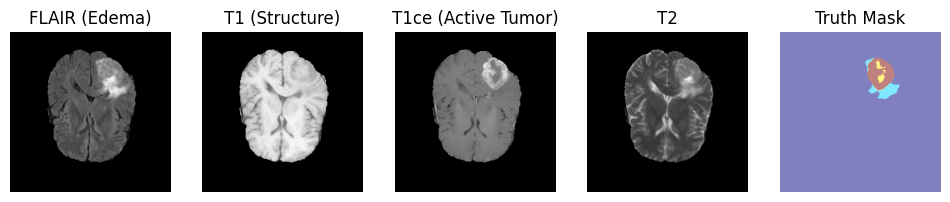

In [ ]:
# Initializing data for training
from monai.data import DataLoader, CacheDataset, decollate_batch
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityd,
    RandCropByPosNegLabeld,
    RandFlipd,
    Lambdad
)

# 1. Define Training Transforms (The "Smart Cropper")
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    ScaleIntensityd(keys=["image"]),


    # --- THE FIX: BINARIZE LABELS ---
    # Convert any label > 0 (1, 2, 4) to just 1.
    # This ensures we only have Class 0 and Class 1.
    Lambdad(keys=["label"], func=lambda x: np.where(x > 0, 1, 0).astype(np.float32)),
    # --------------------------------

    # CROP: Pick 1 tumor area (pos) and 1 background area (neg) per image
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1,
        neg=1,
        num_samples=4,
        image_key="image",
        image_threshold=0,
    ),
])

# 2. Create the Cache (Speed Boost)
# We use a subset (first 20 patients) to make this test run fast.
# If you want to train on ALL 300+ patients later, remove the [:20].
train_files = train_ds.data[:20] 

print(f"Loading {len(train_files)} patients into Cache...")

print("Initializing Cache (Moving images to RAM)...")
train_loader = DataLoader(
    CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0), 
    batch_size=2, 
    shuffle=True,
    num_workers=0
)
print("Data Loader Ready.")

Loading 20 patients into Cache...
Initializing Cache (Moving images to RAM)...


Loading dataset: 100%|██████████| 20/20 [00:11<00:00,  1.73it/s]

Data Loader Ready.


In [ ]:
# Build the 3D U-Net
model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=2,
    channels=(16, 32, 64, 128, 256), # Number of features at each layer
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)

# 2. Loss Function & Optimizer
# Dice Loss is standard for segmentation (measures overlap).
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)

# Metric to track success
dice_metric = DiceMetric(include_background=False, reduction="mean")

print("Model Built on RTX 4080 Super.")

Model Built on RTX 4080 Super.


In [ ]:
# Training for 5 epochs
max_epochs = 5
epoch_loss_values = []

print(f"--- Starting Training for {max_epochs} Epochs ---")

for epoch in range(max_epochs):
    print(f"Epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        
        # Zero Gradients
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(inputs)
        
        # Calculate Loss
        loss = loss_function(outputs, labels)
        
        # Backward Pass
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        print(f"  Step {step}, Loss: {loss.item():.4f}", end="\r") # \r updates the line in place

    # Average loss for the epoch
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"\nEpoch {epoch + 1} Average Loss: {epoch_loss:.4f}")

print("Training Complete!")

--- Starting Training for 5 Epochs ---
Epoch 1/5
  Step 10, Loss: 0.5775
Epoch 1 Average Loss: 0.6105
Epoch 2/5
  Step 10, Loss: 0.6021
Epoch 2 Average Loss: 0.5818
Epoch 3/5
  Step 10, Loss: 0.5803
Epoch 3 Average Loss: 0.5588
Epoch 4/5
  Step 10, Loss: 0.5616
Epoch 4 Average Loss: 0.5627
Epoch 5/5
  Step 10, Loss: 0.4932
Epoch 5 Average Loss: 0.5506
Training Complete!


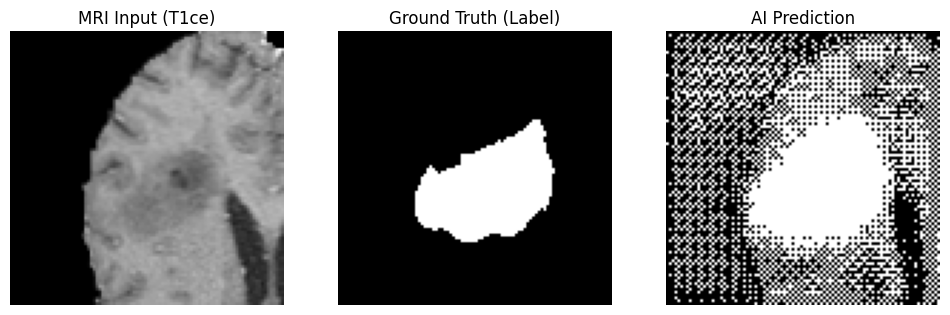

In [ ]:
# Visualizing
import matplotlib.pyplot as plt

# 1. Switch model to "Eval Mode" (No training, just predicting)
model.eval()

# 2. Grab a random patient from the loader
# We use 'decollate' to unpack the batch into single items
data_iter = iter(train_loader)
batch_data = next(data_iter)
images, labels = batch_data["image"].to(device), batch_data["label"].to(device)

# 3. Predict
# inference_roi_size needs to match our crop size (96)
# sliding_window_inference handles the stitching of 3D crops automatically
outputs = sliding_window_inference(
    inputs=images, 
    roi_size=(96, 96, 96), 
    sw_batch_size=4, 
    predictor=model
)

# 4. Process the Output
# Output is (2, H, W, D). We want the "Tumor" channel (Index 1)
# We use Sigmoid to convert raw numbers to Probability (0 to 1)
probs = torch.sigmoid(outputs)
# Threshold: If probability > 0.5, it's a tumor.
preds = (probs > 0.5).float()

# 5. Visualize (The "Doctor's Test")
# We look at Slice 50 (middle of the crop)
slice_idx = 49

plt.figure(figsize=(12, 6))

# A. The MRI Input (Channel 2: T1ce - shows active tumor best)
plt.subplot(1, 3, 1)
plt.title("MRI Input (T1ce)")
plt.imshow(images[0, 2, :, :, slice_idx].cpu().T, cmap="gray")
plt.axis("off")

# B. The Ground Truth (What the Doctor drew)
plt.subplot(1, 3, 2)
plt.title("Ground Truth (Label)")
plt.imshow(labels[0, 0, :, :, slice_idx].cpu().T, cmap="gray")
plt.axis("off")

# C. The AI Prediction
plt.subplot(1, 3, 3)
plt.title("AI Prediction")
plt.imshow(preds[0, 1, :, :, slice_idx].cpu().T, cmap="gray")
plt.axis("off")

plt.show()

In [ ]:
# Saving the model
torch.save(model.state_dict(), "brain_tumor_unet_4080.pth")
print("Model saved successfully.")

Model saved successfully.
